This notebook preprocesses the original Kaggle Retinopath dataset by
* finding the region of interest (the circle of he [fundus photography](https://en.wikipedia.org/wiki/Fundus_photography))
* cropping to that region and rescaling to target size.

See README.md on how to download the full original dataset into `data/retinopathy/original/`.
There should be 88712 images in total here (in `sample`, `test`, `train` subdirs).
Preprocessed images are saved to `data/retinopathy/224/` (or any other target size).

Disk usage:
* original: 90 GiB
* 1024: 4.6 GiB
* 512: 1.6 GiB
* 224: 0.6 GiB

## Imports

In [1]:
import gzip
import json
import shutil
import time
from collections.abc import Sequence
from pathlib import Path
from typing import TypedDict, cast

import cv2
import ipywidgets
import numba
import numpy as np
import pandas as pd
import PIL.Image
import PIL.ImageDraw
from tqdm.contrib.concurrent import process_map

## Images

In [2]:
img_dir = Path("data/retinopathy/original/")
img_paths = list(img_dir.rglob("*.jpeg"))
img_paths = sorted(img_paths, key=lambda p: (int(p.stem.split("_")[0]), p.stem))
len(img_paths)

88712

In [3]:
hard_examples = [
    img_dir / p
    for p in [
        "test/15840_left.jpeg",
        "test/23334_left.jpeg",
        "test/37514_left.jpeg",
        "test/19228_left.jpeg",
        "test/25208_right.jpeg",
        "test/3171_left.jpeg",
        "test/34055_right.jpeg",
        "test/20917_right.jpeg",
        "train/20742_right.jpeg",
        "test/37514_right.jpeg",
        "test/12813_left.jpeg",
        "test/11673_left.jpeg",
        "test/19393_right.jpeg",
        "test/12054_left.jpeg",
        "test/43449_left.jpeg",
        "test/34743_left.jpeg",
        "test/43505_left.jpeg",
        "test/19228_left.jpeg",
        "test/37514_left.jpeg",
        "test/12813_left.jpeg",
        "train/24207_left.jpeg",
        "test/25208_right.jpeg",
        "test/19228_right.jpeg",
        "test/43185_left.jpeg",
        "test/11673_left.jpeg",
        "test/23334_left.jpeg",
        "test/37514_left.jpeg",
        "test/3171_left.jpeg",
        "train/2372_left.jpeg",
        "train/2262_left.jpeg",
        "train/7869_right.jpeg",
        "train/15941_left.jpeg",
        "test/15746_right.jpeg",
        "train/40548_right.jpeg",
        "test/2717_right.jpeg",
    ]
]

## Results
of the circle finding algorithm.

In [4]:
class Result(TypedDict):
    path: str  # Relative to img_dir.
    h: int  # Original image height.
    w: int  # Original image width.
    cy: int  # Center y of the disc (in original image).
    cx: int  # Center x of the disc.
    r: int  # Radius of the disc.
    in_p_dark: float  # Proportion of pixels inside the disc that are dark.
    out_p_dark: float  # Proportion of pixels outside the disc that are dark.

In [5]:
results_path = Path("data/retinopathy/preprocess_results.jsonl.gz")


def load_results() -> dict[Path, Result]:
    results = dict[Path, Result]()
    if results_path.exists():
        with gzip.open(results_path, "rb") as f:
            for line in f:
                d = json.loads(line)
                results[img_dir / d["path"]] = d
    return results


def save_results(results: Sequence[Result]) -> None:
    with gzip.open(results_path, "wb") as f:
        for d in results:
            f.write(json.dumps(d).encode() + b"\n")


results = load_results()

## Show results

In [6]:
if results:
    df = pd.DataFrame.from_dict(results, orient="index")
    df["cy"] = df["cy"] / df["h"]
    df["cx"] = df["cx"] / df["w"]
    df["r"] = df["r"] / ((df["h"] + df["w"]) / 2)
    with pd.option_context("display.precision", 3):
        display(df.head())

,path,h,w,cy,cx,r,in_p_dark,out_p_dark
data/retinopathy/original/test/1_left.jpeg,test/1_left.jpeg,2336,3504,0.509,0.502,0.493,0.045,1.000
data/retinopathy/original/test/1_right.jpeg,test/1_right.jpeg,2336,3504,0.511,0.501,0.493,0.049,1.000
data/retinopathy/original/test/2_left.jpeg,test/2_left.jpeg,1920,2560,0.499,0.500,0.516,0.015,0.999
data/retinopathy/original/test/2_right.jpeg,test/2_right.jpeg,1920,2560,0.499,0.500,0.516,0.015,1.000
data/retinopathy/original/test/3_left.jpeg,test/3_left.jpeg,1920,2560,0.499,0.500,0.503,0.016,0.999


In [7]:
def show(result: Result) -> None:
    print(result)
    pil_img = PIL.Image.open(img_dir / result["path"])
    assert pil_img.mode == "RGB" and pil_img.format == "JPEG"
    draw = PIL.ImageDraw.Draw(pil_img)
    draw.circle(xy=(result["cx"], result["cy"]), radius=result["r"], outline="green", width=10)
    draw.circle(xy=(result["cx"], result["cy"]), radius=30, outline="green", width=10)  # small circle at center.
    display(pil_img.resize((pil_img.width // 8, pil_img.height // 8)))


if results:
    # ordered = cast(Sequence[Path], df.sort_values("in_p_dark", ascending=True).index)
    ordered = hard_examples
    ipywidgets.interact(lambda i: show(results[ordered[i]]), i=ipywidgets.IntSlider(max=len(ordered) - 1, value=0))

interactive(children=(IntSlider(value=0, description='i', max=34), Output()), _dom_classes=('widget-interact',…

## Circle finding algorithm

In [8]:
def find_circle(
    pil_img: PIL.Image.Image, ys: np.ndarray, xs: np.ndarray, rs: np.ndarray, downscale: int, *, debug: bool = False
) -> tuple[float, float, float]:
    """
    Given lists of candidate ys, xs, rs (in original image scale), find the best circle (cy, cx, r).

    Downscaling can be used to speed up the search.
    """
    pil_img = pil_img.reduce(downscale)
    H, W = pil_img.height, pil_img.width
    img = np.array(pil_img).max(axis=2)

    # We look at gradients of pixel brightness (for each pixel, the direction and strength of the biggest change in brightness).
    grad = np.stack((cv2.Scharr(img, cv2.CV_64F, 0, 1), cv2.Scharr(img, cv2.CV_64F, 1, 0)), axis=-1)
    # To prevent large gradients in bright areas from dominating the scores, we divide the gradients by local brightness.
    grad = grad / (img[..., np.newaxis] / img.max() + 0.2)
    # The grid search we do is quite sparse, so we need to smooth the gradients a lot. The K parameter here is quite sensitive...
    K = 25
    grad = np.ascontiguousarray(cv2.GaussianBlur(grad, (K, K), 0))

    scores = get_circle_scores(img, grad, ys / downscale, xs / downscale, rs / downscale)
    b = scores.argmax()
    # best_iy, best_ix, best_ir = np.unravel_index(b, scores.shape)  # numba doesn't support this.
    best_iy, best_ix, best_ir = b // (len(rs) * len(xs)), (b // len(rs)) % len(xs), b % len(rs)
    best_y, best_x, best_r = float(ys[best_iy]), float(xs[best_ix]), float(rs[best_ir])

    if debug:
        grad_img = np.sqrt(grad[..., 0] ** 2 + grad[..., 1] ** 2)
        grad_img = np.uint8(128 + 0.5 * 127 * grad / np.abs(grad).max())
        scores_img = np.uint8(255 * scores.max(axis=2) / np.abs(scores).max())
        display(PIL.Image.fromarray(grad_img).resize((W // 4, H // 4), resample=PIL.Image.Resampling.NEAREST))
        display(PIL.Image.fromarray(scores_img).resize((W // 4, H // 4), resample=PIL.Image.Resampling.NEAREST))

    return best_y, best_x, best_r


@numba.njit
def get_circle_scores(
    img: np.ndarray,  # (H, W), grayscale
    grad: np.ndarray,  # (H, W, 2), precomputed gradients in h and w directions
    ys: np.ndarray,  # Sequence of candidate center ys.
    xs: np.ndarray,  # Sequence of candidate center xs.
    rs: np.ndarray,  # Sequence of candidate radii.
) -> np.ndarray:  # shape (len(ys), len(xs), len(rs))
    """
    Calculates scores of all candidate circles (with centers in ys, xs and radii in rs).

    The score of a candidate circle is calculating as follows:
    - for each of a few directions (e.g. 8 evenly spaced angles),
    - look at the two points on the circle in that direction and the opposite direction,
    - if the gradients are large and roughly point towards the center, add that to the score.
    """
    H, W = img.shape
    scores = np.zeros((len(ys), len(xs), len(rs)), dtype=np.float64)

    angles = np.linspace(0, 160, 8)
    directions = np.stack((np.sin(np.deg2rad(angles)), np.cos(np.deg2rad(angles))), axis=-1)

    for iy, y in enumerate(ys):
        for ix, x in enumerate(xs):
            for ir, r in enumerate(rs):
                scores[iy, ix, ir] = 0
                for d in directions:
                    y0, x0 = int(np.round(y + r * d[0])), int(np.round(x + r * d[1]))
                    y1, x1 = int(np.round(y - r * d[0])), int(np.round(x - r * d[1]))
                    if not (0 <= y0 < H and 0 <= x0 < W and 0 <= y1 < H and 0 <= x1 < W):
                        continue

                    scores[iy, ix, ir] += np.cbrt(
                        np.maximum(grad[y0, x0].dot(-d), 0) * np.maximum(grad[y1, x1].dot(d), 0)
                    )

    return scores


def find_circle_iterative(pil_img: PIL.Image.Image, k: int = 9, iterations: int = 5) -> tuple[int, int, int]:
    """Find the best circle (cy, cx, r) in the image using grid search with iterative refinement."""
    H, W = pil_img.height, pil_img.width
    min_y, max_y = int(0.45 * H), int(0.55 * H)
    min_x, max_x = int(0.45 * W), int(0.55 * W)
    min_r, max_r = int(0.4 * min(H, W)), max(H, W) // 2

    best_y, best_x, best_r = (min_y + max_y) / 2, (min_x + max_x) / 2, (min_r + max_r) / 2

    for i in range(iterations):
        ys, y_step = np.linspace(min_y, max_y, k, retstep=True)
        xs, x_step = np.linspace(min_x, max_x, k + 2, retstep=True)
        rs, r_step = np.linspace(min_r, max_r, 2 * k, retstep=True)

        target_size = 1536 // 2 ** min(iterations - 1 - i, 2)
        best_y, best_x, best_r = find_circle(pil_img, ys, xs, rs, downscale=max(1, min(H, W) // target_size))

        min_y, max_y = best_y - 1.2 * y_step, best_y + 1.2 * y_step
        min_x, max_x = best_x - 1.2 * x_step, best_x + 1.2 * x_step
        min_r, max_r = best_r - 1.2 * r_step, best_r + 1.2 * r_step

    best_y = max(0, min(H - 1, best_y))
    best_x = max(0, min(W - 1, best_x))
    best_r = max(1, best_r)
    return (round(best_y), round(best_x), round(best_r))

In [9]:
def process(img_path: Path) -> Result:
    pil_img = PIL.Image.open(img_path)
    assert pil_img.mode == "RGB" and pil_img.format == "JPEG"

    cy, cx, r = find_circle_iterative(pil_img)

    # Calculate some brightness statistics about the inside and outside of the circle.
    img = np.array(pil_img).max(axis=2)
    y, x = np.indices(img.shape)
    in_mask = ((y - cy) ** 2 + (x - cx) ** 2) <= r**2
    # in_q = np.quantile(img[in_mask], [0.0, 0.1, 0.5, 0.9, 0.95, 0.99, 1.0], method="higher").astype(np.uint8)
    # out_q = np.quantile(img[~in_mask], [0.0, 0.1, 0.5, 0.9, 0.95, 0.99, 1.0], method="higher").astype(np.uint8)
    in_p_dark = (img[in_mask] < 30).mean()
    out_p_dark = (img[~in_mask] < 30).mean()

    return {
        "path": str(img_path.relative_to(img_dir)),
        "h": pil_img.height,
        "w": pil_img.width,
        "cy": cy,
        "cx": cx,
        "r": r,
        "in_p_dark": round(float(in_p_dark), 4),
        "out_p_dark": round(float(out_p_dark), 4),
    }


def process_and_show(img_path: Path) -> Result:
    start_time = time.time()
    result = process(img_path)
    print(f"Processing took {time.time() - start_time:.2f} seconds.")
    show(result)
    return result


ordered = cast(Sequence[Path], df.sort_values("r", ascending=True).index)
# sorted = hard_examples
ipywidgets.interact(lambda i: process_and_show(ordered[i]), i=ipywidgets.IntSlider(max=len(ordered) - 1, value=0));

interactive(children=(IntSlider(value=0, description='i', max=88711), Output()), _dom_classes=('widget-interac…

## Process all images
(This can take a few hours).

In [10]:
remaining_img_paths = [p for p in img_paths if p not in results.keys()]
print(f"{len(results)} results loaded, {len(remaining_img_paths)} images remaining")

88712 results loaded, 0 images remaining


In [11]:
if False:
    LIMIT = 1000
    new_results = process_map(process, remaining_img_paths[:LIMIT], max_workers=12, chunksize=1, smoothing=0.01)

    for r in new_results:
        results[img_dir / r["path"]] = r
    save_results(list(results.values()))

## Crop and rescale

In [19]:
def crop_and_rescale(img_path: Path, target_size: int = 224) -> tuple[PIL.Image.Image, dict]:
    pil_img = PIL.Image.open(img_path)
    assert pil_img.mode == "RGB" and pil_img.format == "JPEG"
    result = results[img_path]
    cy, cx, r = result["cy"], result["cx"], result["r"]
    H, W = pil_img.height, pil_img.width

    crop_r = int(1.01 * r)
    left, right = max(0, cx - crop_r), min(W, cx + crop_r)
    top, bottom = max(0, cy - crop_r), min(H, cy + crop_r)

    cropH, cropW = bottom - top, right - left
    if cropW >= cropH:
        newH, newW = int(target_size * cropH / cropW), target_size
    else:
        newH, newW = target_size, int(target_size * cropW / cropH)

    meta = {"box": [left, top, right, bottom], "newH": newH, "newW": newW}
    pil_img = pil_img.resize((newW, newH), box=(left, top, right, bottom), resample=PIL.Image.Resampling.BILINEAR)
    if newH > newW:
        print("Warning: Rotating image to make it landscape: ", img_path)
        pil_img = pil_img.rotate(90, expand=True)
    return pil_img, meta


def show_crop(img_path: Path, target_size: int = 224) -> None:
    pil_img, meta = crop_and_rescale(img_dir / results[img_path]["path"], target_size)
    print(results[img_path])
    print(meta)
    display(pil_img)


ordered = cast(Sequence[Path], df.sort_values("r", ascending=True).index)
ipywidgets.interact(lambda i: show_crop(ordered[i]), i=ipywidgets.IntSlider(max=len(ordered) - 1, value=100));

interactive(children=(IntSlider(value=100, description='i', max=88711), Output()), _dom_classes=('widget-inter…

In [ ]:
target_size = 224
target_img_dir = Path(f"data/retinopathy/{target_size}/")
for p in ["test", "train", "sample"]:
    (target_img_dir / p).mkdir(parents=True, exist_ok=True)
for p in ["sampleSubmission.csv", "testLabels.csv", "trainLabels.csv"]:
    shutil.copyfile(img_dir / p, target_img_dir / p)

def process_crop(img_path: Path) -> dict:
    target_img_path = target_img_dir / results[img_path]["path"]
    pil_img, meta = crop_and_rescale(img_dir / results[img_path]["path"], target_size)
    pil_img.save(target_img_path)
    return results[img_path] | meta


new_metas = process_map(process_crop, list(results.keys()), max_workers=8, chunksize=1, smoothing=0.01)

<Axes: >

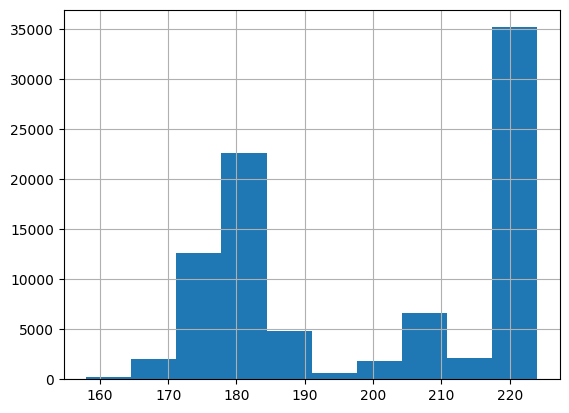

In [14]:
new_df = pd.DataFrame(new_metas)
new_df["newH"].hist()

In [25]:
ordered = cast(Sequence[Path],  df.index[new_df.sort_values("newW", ascending=True).index])
ipywidgets.interact(lambda i: show_crop(ordered[i], target_size), i=ipywidgets.IntSlider(max=len(ordered) - 1, value=0));

interactive(children=(IntSlider(value=0, description='i', max=88711), Output()), _dom_classes=('widget-interac…

## Check datamodule

In [37]:
from prox_lora.datasets.diabetic_retinopathy import DRConfig
from prox_lora.datasets.transforms import OPENAI_DATASET_MEAN, OPENAI_DATASET_STD, to_pil_image

data_module = DRConfig(augmentations=True, size=224).instantiate()
data_module.setup()
dataset = data_module.train_dataset

ipywidgets.interact(lambda i: to_pil_image(dataset[i][0], OPENAI_DATASET_MEAN, OPENAI_DATASET_STD), i=ipywidgets.IntSlider(max=len(dataset) - 1, value=0));

interactive(children=(IntSlider(value=0, description='i', max=31613), Output()), _dom_classes=('widget-interac…